# Logistic regression for concrete strength classification

In this notebook, we repeat the concrete strength classification exercise (introduced with the linear discriminant analysis notebook) with logistic regression. Rather than predicting the compressive strength from a regression perspective, we discretize the target variable into three strength classes:
- Low strength: $f_c < 25\ \text{MPa}$
- Medium strength: $25 \leq f_c \leq 40\ \text{MPa}$
- High strength: $f_c > 40\ \text{MPa}$
  
We will then reformulate the original regression problem as a multiclass classification problem and address it with logistic regression. Unlike linear discriminant analysis, logistic regression does not assume that the features follow Gaussian distributions. Instead, it directly models the posterior probability of each class by maximizing the likelihood of the observed labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

### Load data

The dataset contains:
- Input variables describing the concrete composition
- One target variable corresponding to the concrete compressive strength

In [2]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)
# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

# Display the first rows of the dataset
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values # All columns except last → input features
y = df.iloc[1:, -1].values # Last column → target

N, d = X.shape

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print(f"Number of samples: {N}")
print(f"Number of input features: {d}")

Input shape: (1029, 8)
Target shape: (1029,)
Number of samples: 1029
Number of input features: 8


### Convert compressive strength into strength classes

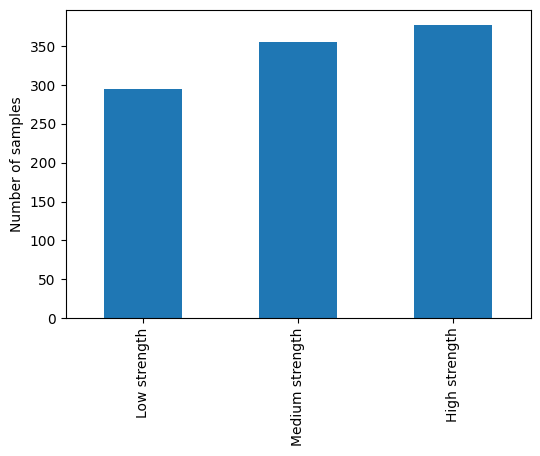

In [4]:
# Strength intervals (MPa)
bins = [0, 25, 40, np.inf]

class_names = ["Low strength", "Medium strength", "High strength",]

y_class = pd.cut(y,bins=bins,labels=class_names)

plt.figure(figsize=(6,4))
y_class.value_counts().sort_index().plot.bar()

plt.ylabel("Number of samples")

plt.show()

### Split and normalize the data

LDA estimates covariance matrices, variables should therefore have comparable scales.

- Split using 80% train and 20% test
- Compute normalization statistics from training data
- Consistently apply normalization to the test data

In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=4, stratify=y_class)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train the logistic regression model

Scikit-learn automatically performs multinomial logistic regression when more than two classes are present. The model estimates one linear decision function for each class and converts these scores into probabilities through the Softmax function.

In [6]:
logreg = LogisticRegression(solver="lbfgs",max_iter=1000)

logreg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Prediction and visualization

The performance of a classifier can be evaluated by comparing its predictions with the ground-truth labels. A convenient way to summarize the classification results is with a confusion matrix, which reports the number of correctly and incorrectly classified samples.

The confusion matrix is often complemented by the accuracy metric, which measures the proportion of correctly classified samples.

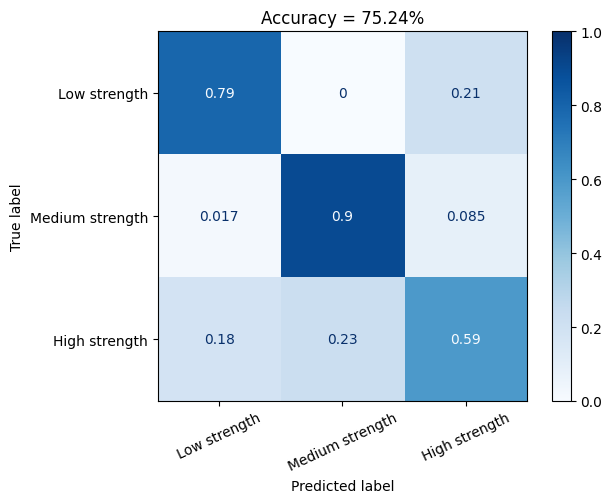

In [7]:
y_pred = logreg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low strength", "Medium strength", "High strength"])
disp.plot(cmap='Blues', xticks_rotation=25)
disp.im_.set_clim(0, 1)
plt.title(f"Accuracy = {accuracy:.2%}")
plt.show()

### Posterior probabilities

One of the main advantages of logistic regression is that it directly estimates class probabilities. These probabilities can be interpreted as the confidence of the classifier in each prediction.

In [8]:
probabilities = logreg.predict_proba(X_test_scaled)

pd.DataFrame(probabilities[:10], # Display only the first ten instances
             columns=class_names)

,Low strength,Medium strength,High strength
0,0.824105,0.010341,0.165554
1,0.345003,0.140085,0.514911
2,0.260729,0.001902,0.737369
3,0.214145,0.106503,0.679352
4,0.266830,0.329806,0.403364
5,0.029284,0.763675,0.207041
6,0.450847,0.030158,0.518996
7,0.010301,0.852735,0.136964
8,0.034385,0.723949,0.241666
9,0.023062,0.786541,0.190396


### Model coefficients

Each class is associated with a linear model $a_k(\mathbf{x})=\mathbf{x}^T\boldsymbol{\beta}_k$. Large positive entries in the parameter vector $\boldsymbol{\beta}_k$ indicate that increasing the corresponding feature increases the probability of belonging to that class. We can create an heatmap showing which variables drive each class.

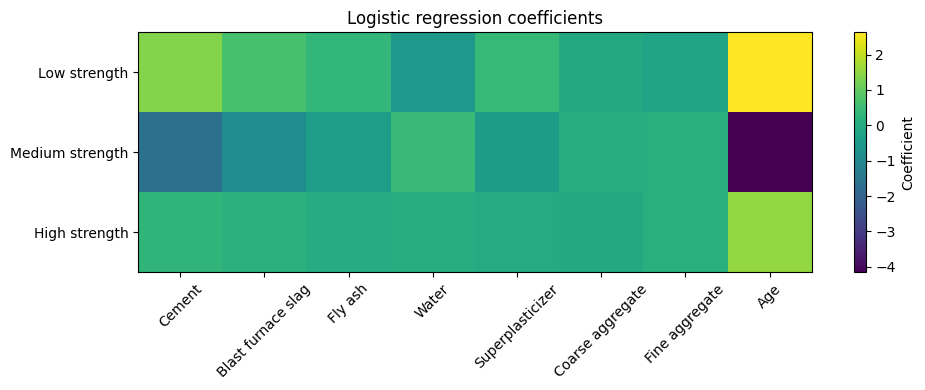

In [9]:
feature_names = ["Cement", "Blast furnace slag", "Fly ash", "Water", "Superplasticizer", "Coarse aggregate", "Fine aggregate", "Age"]
                                                                                                                                                                                                                                                                                                                                                                                                          
coef = pd.DataFrame(logreg.coef_, columns=feature_names, index=logreg.classes_)

plt.figure(figsize=(10,4))
plt.imshow(coef, aspect="auto")

plt.xticks(np.arange(len(feature_names)), feature_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

plt.colorbar(label="Coefficient")
plt.title("Logistic regression coefficients")
plt.tight_layout()

### Exercises

- Compare the classification accuracy of logistic regression and LDA.
  
- Inspect the learned coefficients. Which concrete properties contribute the most to each strength class?

- Investigate how changing the regularization parameter `C` affects the classification results.

- Compare the posterior probabilities produced by logistic regression with those obtained using LDA.